# Multiple Linear Regression Analysis in Python- ISLP Chapter 3
**Annalise Banda | STA 6543**


# Q2
Carefully explain the differences between the KNN classifier and KNN regression methods.

KNN classifier and KNN regression both work by first identifying the K nearest neighbors to a given data point, typically based on distance. The key difference lies in how they use those neighbors to make a prediction. KNN classifier is used when the response variable is categorical (ex.Yes/No). It predicts the class by majority vote, whichever category appears most frequently among the K nearest neighbors is chosen as the predicted class. KNN regression, on the other hand, is used when the response variable is continuous/numerical. Instead of voting, it predicts a value by taking the average of the K nearest neighbors' numerical values. In short, classification predicts a category through majority vote, while regression predicts a number through averaging. 

# Q9
This question involves the use of multiple linear regression on the
Auto data set.

(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method. .corr()

(c) Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output. For instance:

i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to
answer this question.
ii. Which predictors appear to have a statistically significant
relationship to the response?
iii. What does the coefficient for the year variable suggest?

(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?

(f) Try a few different transformations of the variables, such as
log(X),√X, X2. Comment on your findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

In [2]:
from ISLP import load_data
Auto = load_data('Auto')
Auto = Auto.dropna()
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


### (a) Scatterplot Matrix

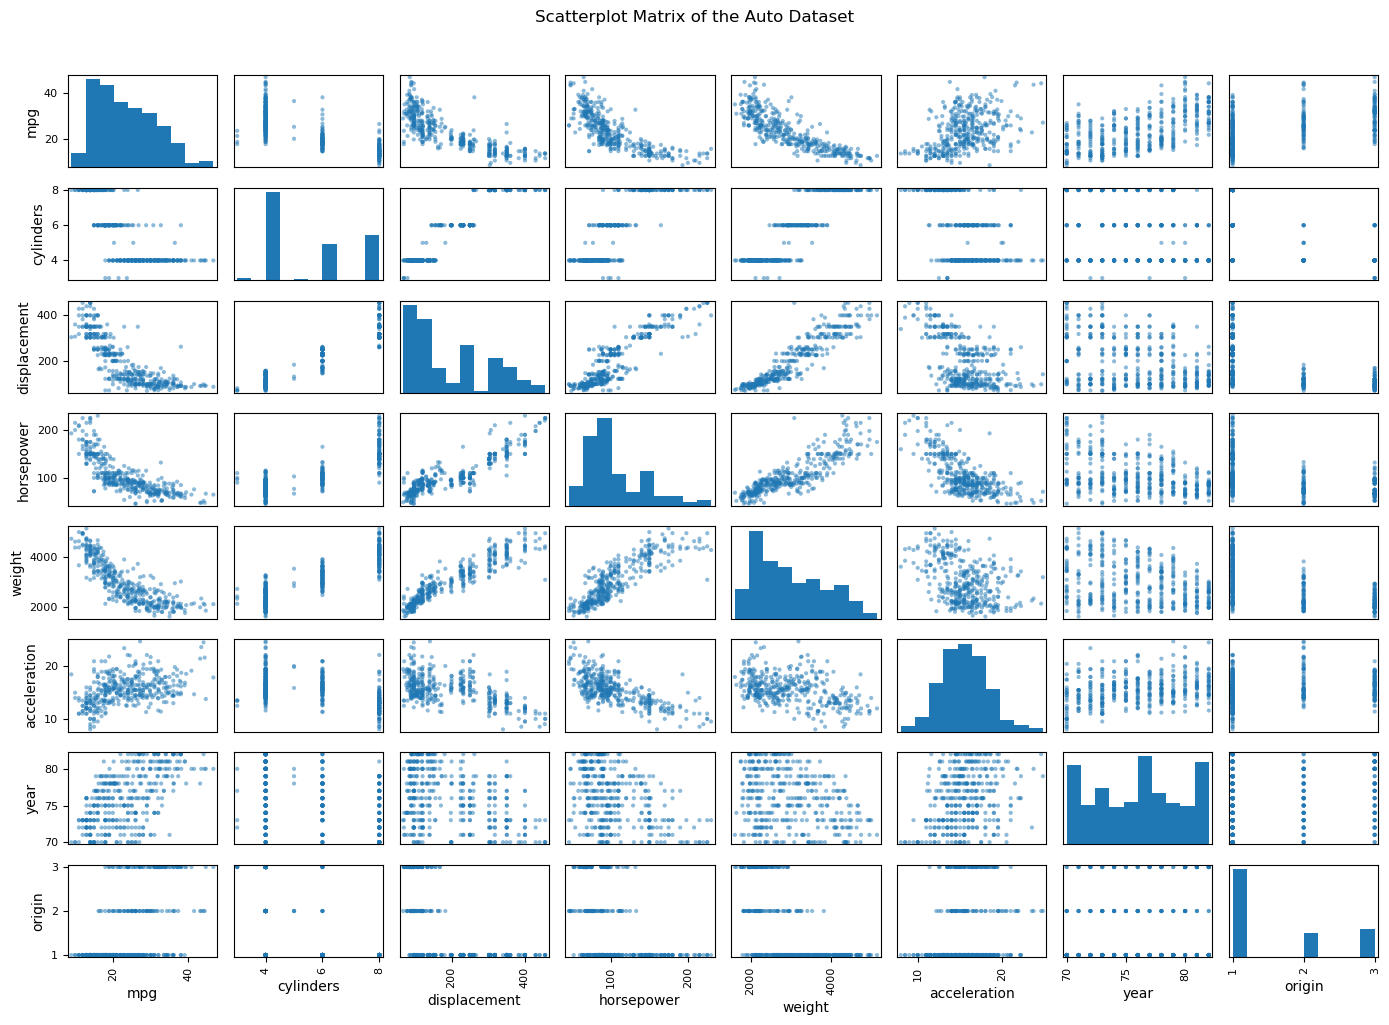

In [3]:
pd.plotting.scatter_matrix(Auto, figsize=(14,10))
plt.suptitle("Scatterplot Matrix of the Auto Dataset", y=1.02)
plt.tight_layout()
plt.show()

The scatterplot matrix shows several clear relationships among the variables. The response variable, mpg, has a strong negative relationship with cylinders, displacement, horsepower, and weight, indicating that larger and heavier cars generally have lower fuel efficiency. In contrast, mpg has a positive relationship with year, suggesting that newer vehicles tend to achieve better gas mileage. Several predictor variables, such as displacement, horsepower, and weight are also strongly correlated with one another, which may indicate multicollinearity in the regression model. Additionally, cylinders and origin appear as distinct vertical bands in the scatterplot matrix rather than smooth scatter patterns, reflecting their categorical nature. Cylinders only takes values of 3, 4, 5, 6, or 8, while origin represents only three categories (American, European, and Japanese).

### (b) Correlation Matrix

In [4]:
Auto.corr().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.00,-0.78,-0.81,-0.78,-0.83,0.42,0.58,0.57
cylinders,-0.78,1.00,0.95,0.84,0.90,-0.50,-0.35,-0.57
displacement,-0.81,0.95,1.00,0.90,0.93,-0.54,-0.37,-0.61
horsepower,-0.78,0.84,0.90,1.00,0.86,-0.69,-0.42,-0.46
weight,-0.83,0.90,0.93,0.86,1.00,-0.42,-0.31,-0.59
acceleration,0.42,-0.50,-0.54,-0.69,-0.42,1.00,0.29,0.21
year,0.58,-0.35,-0.37,-0.42,-0.31,0.29,1.00,0.18
origin,0.57,-0.57,-0.61,-0.46,-0.59,0.21,0.18,1.00


The correlation matrix shows several strong relationships among the variables. The response variable, mpg, is negatively correlated with cylinders, displacement, horsepower, and weight, indicating that larger and heavier vehicles generally have lower fuel efficiency. In contrast, year is positively correlated with mpg, suggesting that newer vehicles tend to achieve better gas mileage. Several predictor variables are also highly correlated with one another, particularly displacement, horsepower, and weight, which may indicate multicollinearity. 

### (c) Multiple Linear Regression

In [5]:
X = Auto.drop(columns='mpg')
y = Auto['mpg']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          2.04e-139
Time:                        15:01:52   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

anova_model = smf.ols(
    'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin',
    data=Auto
).fit()

anova_lm(anova_model)

,df,sum_sq,mean_sq,F,PR(>F)
cylinders,1.0,14403.083079,14403.083079,1300.683788,2.319511e-125
displacement,1.0,1073.344025,1073.344025,96.929329,1.530906e-20
horsepower,1.0,403.408069,403.408069,36.430140,3.731128e-09
weight,1.0,975.724953,975.724953,88.113748,5.544461e-19
acceleration,1.0,0.966071,0.966071,0.087242,7.678728e-01
year,1.0,2419.120249,2419.120249,218.460900,1.875281e-39
origin,1.0,291.134494,291.134494,26.291171,4.665681e-07
Residual,384.0,4252.212530,11.073470,NaN,NaN


i. The overall regression model is statistically significant. The F-statistic of 252.4 with a p-value of 2.04e-139 is far below the 0.05 threshold, which tells us that the predictors as a group explain a significant amount of the variation in mpg. Additionally, the $R^2$ value of 0.821 indicates that approximately 82% of the variation in mpg is explained by the model, suggesting a strong overall fit. 

ii. Displacement, weight, year, and origin appear to be statistically significant predictors of mpg. The non-significant predictors are cylinders, horsepower, and acceleration. 

iii. The coefficient for year is positive, suggesting that newer vehicles tend to have better fuel efficiency. Holding all other variables constant, each one-year increase in model year is associated with an average increase of about 0.75 mpg.


### (d) Diagnostic Plots

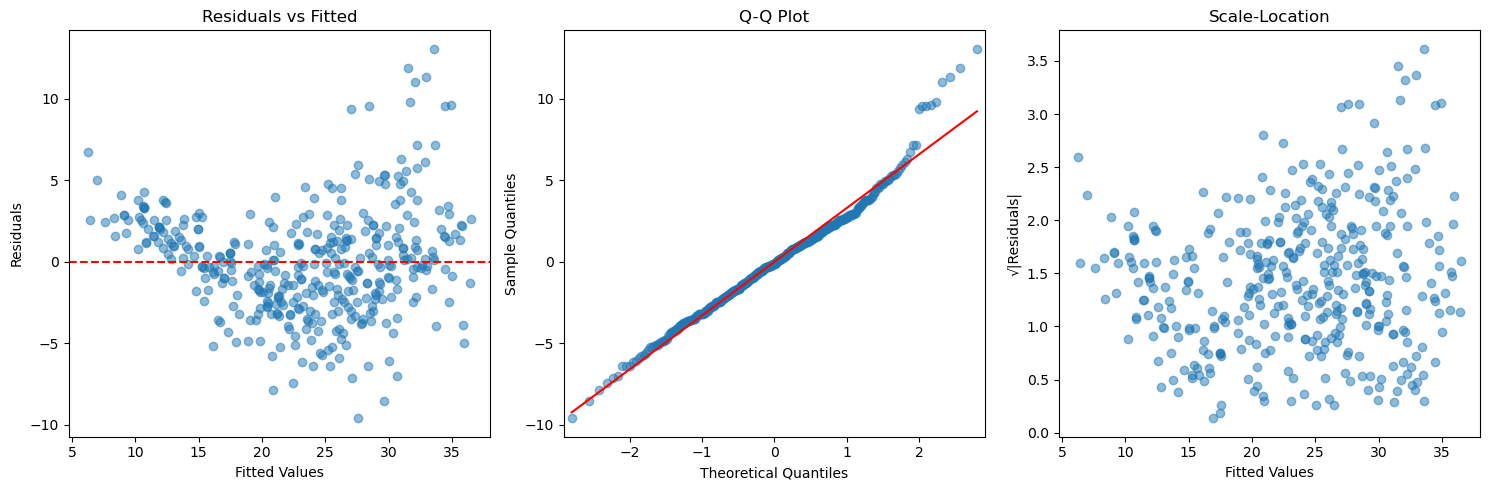

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Residuals vs Fitted
fitted = model.fittedvalues
residuals = model.resid
axes[0].scatter(fitted, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Plot')

# 3. Scale-Location
import numpy as np
axes[2].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('√|Residuals|')
axes[2].set_title('Scale-Location')

plt.tight_layout()
plt.show()

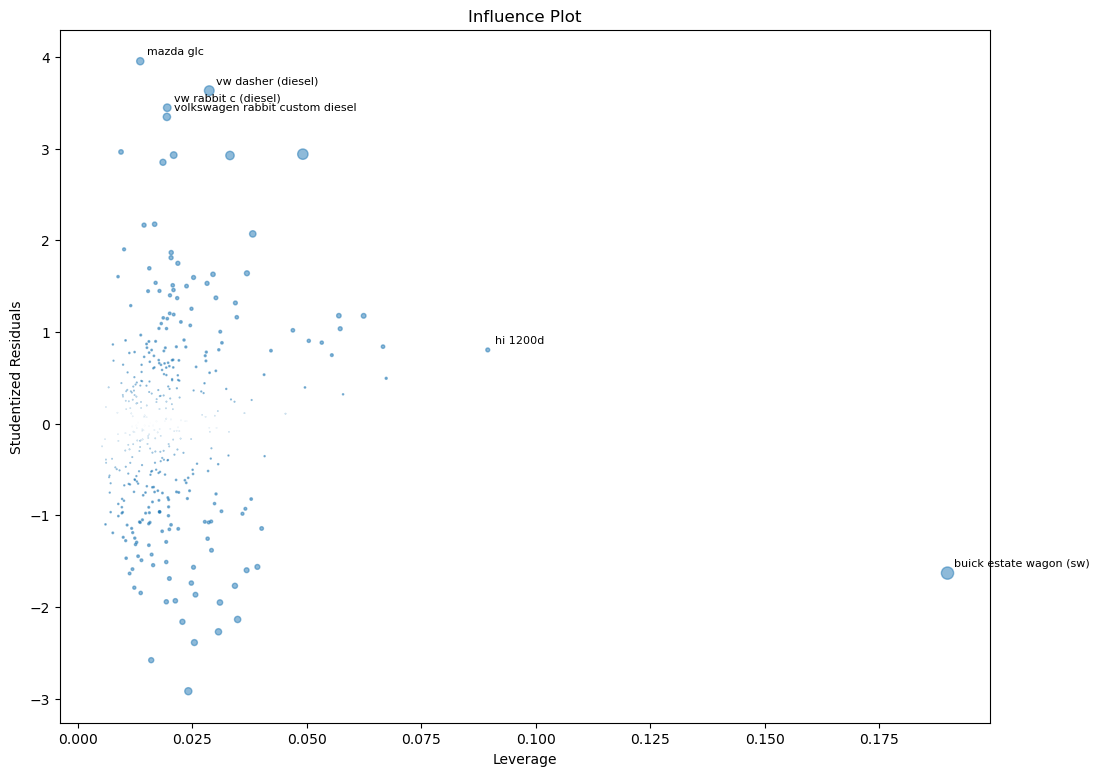

In [8]:
fig, ax = plt.subplots(figsize=(12,9))

influence = model.get_influence()
leverage = influence.hat_matrix_diag
resid_student = influence.resid_studentized_internal
cooks = influence.cooks_distance[0]

ax.scatter(leverage, resid_student, s=1000*cooks, alpha=0.5)
ax.set_xlabel('Leverage')
ax.set_ylabel('Studentized Residuals')
ax.set_title('Influence Plot')

for i in range(len(leverage)):
    if leverage[i] > 0.08 or abs(resid_student[i]) > 3:
        ax.annotate(Auto.index[i], (leverage[i], resid_student[i]), fontsize=8,
                     xytext=(5,5), textcoords='offset points')

plt.show()

The Residuals vs Fitted plot shows a slight non-linear, curved pattern, suggesting the true relationship between the predictors and mpg may not be perfectly linear. 
The Scale-Location plot shows mild heteroscedasticity, the variance of residuals increases slightly at higher fitted values, indicating the model's errors are not perfectly consistent across all predictions. 
The Q-Q plot shows residuals are approximately normally distributed overall, though a few points deviate at the upper tail, indicating some unusually large outliers in the 25-35 range of fitted values, with residuals exceeding 10 or -10. 
The influence plot identifies the Buick Estate Wagon as having unusually high leverage, meaning this observation has an unusually strong influence on the regression coefficients compared to other cars in the dataset. 

Overall, while the model fits reasonably well, these diagnostics suggest mild violations of the linearity and constant variance assumptions, along with a few influential points worth noting.

### (e) Interaction Models

In [9]:
import statsmodels.formula.api as smf

interaction_model = smf.ols(
    'mpg ~ horsepower + displacement + weight + horsepower:displacement + weight:displacement',
    data=Auto
).fit()

interaction_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     240.9
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          2.70e-116
Time:                        15:01:52   Log-Likelihood:                -1083.6
No. Observations:                 392   AIC:                             2179.
Df Residuals:                     386   BIC:                             2203.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  56.4027      2.007     28.107      0.000      52.457      60.348
horsepower                 -0.1724      0.028     -6.247      0.000      -0.227      -0.118
displacement               -0.0786      0.011     -7.337      0.000      -0.100      -0.058
weight                     -0.0045      0.001     -3.320      0.001      -0.007      -0.002
horsepower:displacement     0.0004   9.13e-05      4.217      0.000       0.000       0.001
weight:displacement      6.739e-06   4.47e-06      1.508      0.132   -2.05e-06    1.55e-05
==============================================================================
Omnibus:                       43.262   Durbin-Watson:                   0.954
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               79.829
Skew:                           0.649   Prob(JB):                     4.63e-18
Kurtosis:                       4.790   Cond. No.                     8.67e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.67e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

For my interaction model, I chose to test the interactions between horsepower and displacement, as well as weight and displacement, based on the relationships I noticed in the scatterplot matrix earlier. 
Horsepower and displacment proved to be statistically significant with a p-value of 0.000, which is far less than 0.05, suggesting that the effect of horsepower on mpg depends on engine displacement, likely due to larger engines requiring more fuel to move, changing how efficiently horsepower translates to mpg. Displacement and weight, however, were not statistically significant (p = 0.132).

#### Additional Exploration: Testing Horsepower:Weight

In [10]:
interaction_model2 = smf.ols(
    'mpg ~ horsepower + displacement + weight + horsepower:displacement + horsepower:weight',
    data=Auto
).fit()

interaction_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     240.2
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          4.29e-116
Time:                        15:01:53   Log-Likelihood:                -1084.1
No. Observations:                 392   AIC:                             2180.
Df Residuals:                     386   BIC:                             2204.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  57.2978      2.889     19.835      0.000      51.618      62.977
horsepower                 -0.2204      0.028     -7.794      0.000      -0.276      -0.165
displacement               -0.0569      0.016     -3.628      0.000      -0.088      -0.026
weight                     -0.0047      0.002     -2.566      0.011      -0.008      -0.001
horsepower:displacement     0.0004      0.000      3.438      0.001       0.000       0.001
horsepower:weight         1.51e-05    1.3e-05      1.160      0.247   -1.05e-05    4.07e-05
==============================================================================
Omnibus:                       41.396   Durbin-Watson:                   0.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               74.837
Skew:                           0.631   Prob(JB):                     5.62e-17
Kurtosis:                       4.728   Cond. No.                     5.99e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.99e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Out of curiosity, I also tested an interaction between horsepower and weight in place of weight and displacement. This interaction was not statistically significant (p = 0.247), and the model's R-squared remained unchanged at 0.757. This suggests that displacement plays a more meaningful interaction role with horsepower than weight does. Likely due to displacement and horsepower both being direct measures of engine power and size, whereas weight reflects the overall vehicle rather than the engine itself.

### (f) Transformations

In [11]:
log_model = smf.ols(
    'mpg ~ np.log(horsepower) + displacement + weight + acceleration + year + cylinders + origin',
    data=Auto
).fit()

log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     281.6
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          5.80e-147
Time:                        15:01:53   Log-Likelihood:                -1005.7
No. Observations:                 392   AIC:                             2027.
Df Residuals:                     384   BIC:                             2059.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             27.2540      8.590      3.173      0.002      10.365      44.143
np.log(horsepower)    -9.5064      1.540     -6.175      0.000     -12.534      -6.479
displacement           0.0195      0.007      2.830      0.005       0.006       0.033
weight                -0.0043      0.001     -6.148      0.000      -0.006      -0.003
acceleration          -0.2921      0.104     -2.814      0.005      -0.496      -0.088
year                   0.7053      0.048     14.556      0.000       0.610       0.801
cylinders             -0.4862      0.307     -1.585      0.114      -1.089       0.117
origin                 1.4824      0.259      5.716      0.000       0.973       1.992
==============================================================================
Omnibus:                       29.129   Durbin-Watson:                   1.420
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.738
Skew:                           0.501   Prob(JB):                     7.10e-11
Kurtosis:                       4.362   Cond. No.                     1.68e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.68e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
sq_model = smf.ols(
    'mpg ~ np.log(horsepower) + displacement + np.power(weight, 2) + acceleration + year + cylinders + origin',
    data=Auto
).fit()

sq_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     258.4
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          5.26e-141
Time:                        15:01:53   Log-Likelihood:                -1019.7
No. Observations:                 392   AIC:                             2055.
Df Residuals:                     384   BIC:                             2087.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              42.5266      8.675      4.902      0.000      25.470      59.583
np.log(horsepower)    -13.1025      1.460     -8.973      0.000     -15.974     -10.231
displacement            0.0102      0.007      1.416      0.158      -0.004       0.024
np.power(weight, 2) -2.879e-07    9.8e-08     -2.939      0.003   -4.81e-07   -9.53e-08
acceleration           -0.5200      0.100     -5.188      0.000      -0.717      -0.323
year                    0.6661      0.050     13.418      0.000       0.569       0.764
cylinders              -0.5973      0.317     -1.883      0.060      -1.221       0.026
origin                  1.6182      0.270      6.002      0.000       1.088       2.148
==============================================================================
Omnibus:                       29.283   Durbin-Watson:                   1.432
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.823
Skew:                           0.521   Prob(JB):                     1.85e-10
Kurtosis:                       4.288   Cond. No.                     5.81e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.81e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
log_weight_model = smf.ols(
    'mpg ~ np.log(horsepower) + displacement + np.log(weight) + acceleration + year + cylinders + origin',
    data=Auto
).fit()

log_weight_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     315.3
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          6.63e-155
Time:                        15:01:53   Log-Likelihood:                -986.98
No. Observations:                 392   AIC:                             1990.
Df Residuals:                     384   BIC:                             2022.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            131.0533     11.006     11.907      0.000     109.413     152.694
np.log(horsepower)    -6.1666      1.548     -3.985      0.000      -9.209      -3.124
displacement           0.0211      0.006      3.354      0.001       0.009       0.033
np.log(weight)       -17.3701      1.941     -8.947      0.000     -21.187     -13.553
acceleration          -0.1121      0.101     -1.106      0.269      -0.311       0.087
year                   0.7525      0.047     16.073      0.000       0.660       0.845
cylinders             -0.4350      0.292     -1.488      0.138      -1.010       0.140
origin                 1.1313      0.251      4.500      0.000       0.637       1.626
==============================================================================
Omnibus:                       37.340   Durbin-Watson:                   1.442
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               70.831
Skew:                           0.560   Prob(JB):                     4.16e-16
Kurtosis:                       4.756   Cond. No.                     1.68e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.68e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
comparison = pd.DataFrame({
    'Model': ['Original', 'log(horsepower)', 'log(horsepower) + weight²', 'log(horsepower) + log(weight)'],
    'R-squared': [0.821, 0.837, 0.825, 0.852]
}).set_index('Model')

comparison

,R-squared
Model,
Original,0.821
log(horsepower),0.837
log(horsepower) + weight²,0.825
log(horsepower) + log(weight),0.852


To explore whether transformations could improve model fit, I tested three approaches: $\log(\text{horsepower})$, $weight^2$ (combined with $\log(\text{horsepower})$), and $\log(\text{weight})$ (combined with $\log(\text{horsepower})$). 

The original model without transformations had an $R^2$ of 0.821. Applying $\log(\text{horsepower})$ alone improved this to 0.837, suggesting horsepower's relationship with mpg is better captured as a curve than a straight line. Adding $weight^2$ on top of $\log(\text{horsepower})$ actually decreased the $R^2$ slightly to 0.825, suggesting that squaring weight did not better capture its relationship with mpg. Likely because the weight-mpg relationship, while negative, was already closer to linear than horsepower's relationship was. 
However, replacing $weight^2$ with $\log(\text{weight})$ produced the best-performing model, with an $R^2$ of 0.852, the highest of all models tested. 

This suggests that both horsepower and weight have relationships with mpg that are better described on a logarithmic scale rather than a purely linear or squared scale, which makes intuitive sense since diminishing returns are common in mechanical systems. For example, each additional pound of weight or unit of horsepower has a progressively smaller (or larger) effect on fuel efficiency rather than a constant one. 

Overall, these results highlight that transformations should be tested empirically rather than assumed, since not every transformation improves model fit equally.

# Q10
This question should be answered using the Carseats data set.

(a) Fit a multiple regression model to predict Sales using Price,
Urban, and US.

(b) Provide an interpretation of each coefficient in the model. Be
careful—some of the variables in the model are qualitative!

(c) Write out the model in equation form, being careful to handle
the qualitative variables properly.

(d) For which of the predictors can you reject the null hypothesis
H0 : βj =0?

(e) On the basis of your response to the previous question, fit a
smaller model that only uses the predictors for which there is
evidence of association with the outcome.

(f) How well do the models in (a) and (e) fit the data?

(g) Using the model from (e), obtain 95 % confidence intervals for
the coefficient(s).

(h) Is there evidence of outliers or high leverage observations in the
model from (e)?

In [15]:
Carseats = load_data('Carseats')
Carseats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sales        400 non-null    float64 
 1   CompPrice    400 non-null    int64   
 2   Income       400 non-null    int64   
 3   Advertising  400 non-null    int64   
 4   Population   400 non-null    int64   
 5   Price        400 non-null    int64   
 6   ShelveLoc    400 non-null    category
 7   Age          400 non-null    int64   
 8   Education    400 non-null    int64   
 9   Urban        400 non-null    category
 10  US           400 non-null    category
dtypes: category(3), float64(1), int64(7)
memory usage: 26.7 KB


### (a)

In [16]:
model_a = smf.ols('Sales ~ Price + Urban + US', data=Carseats).fit()
model_a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           2.39e-23
Time:                        15:01:53   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036      0.000      11.764      14.323
Urban[T.Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[T.Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
Price           -0.0545      0.005    -10.389      0.000      -0.065      -0.044
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### (b) Interpreting Carseats coefficients

A one dollar increase in Price is associated with a decrease of approximately 55 carseats sold, holding all other variables constant. Urban stores sell approximately 22 fewer carseats compared to Non-Urban stores, though this relationship is not statistically significant (p = 0.936). US stores sell approximately 1,200 more carseats compared to Non-US stores, holding all other variables constant.

### (c)


$$Sales = 13.0435 - 0.0545(Price) - 0.0219(Urban) + 1.2006(US)$$

Where:
- $Urban = 1$ if the store is in an urban location, 0 otherwise
- $US = 1$ if the store is in the US, 0 otherwise

### (d)

We can reject the null hypothesis $H_0: \beta_j = 0$ for **Price** and **US**, 
as both have p-values of 0.000, which is far below the 0.05 significance 
threshold. We fail to reject the null hypothesis for **Urban** (p = 0.936), 
suggesting there is no statistically significant relationship between whether 
a store is in an urban location and Sales.

### (e)

In [17]:
model_e = smf.ols('Sales ~ Price + US', data=Carseats).fit()
model_e.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           2.66e-24
Time:                        15:01:53   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.000      11.790      14.271
US[T.Yes]      1.1996      0.258      4.641      0.000       0.692       1.708
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### (f)

In [18]:
comparison_f = pd.DataFrame({
    'Model': ['Full Model (a) - Price, Urban, US', 'Reduced Model (e) - Price, US'],
    'R-squared': [0.239, 0.239],
    'Adj. R-squared': [0.234, 0.235],
    'F-statistic': [41.52, 62.43],
    'AIC': [1863, 1861]
}).set_index('Model')

comparison_f

,R-squared,Adj. R-squared,F-statistic,AIC
Model,,,,
"Full Model (a) - Price, Urban, US",0.239,0.234,41.52,1863
"Reduced Model (e) - Price, US",0.239,0.235,62.43,1861


Comparing the full model (a) and the reduced model (e), the $R^2$ remained 
identical at 0.239 for both models, suggesting that removing **Urban** did 
not reduce the model's ability to explain variation in Sales — confirming 
that Urban contributes little to no explanatory power. However, the Adjusted 
$R^2$ increased slightly from 0.234 to 0.235 in the reduced model, indicating 
that removing the non-significant **Urban** predictor actually improved the 
model by eliminating an unnecessary variable. The AIC also decreased slightly 
from 1863 to 1861, further supporting the reduced model. Overall, the reduced 
model (e) is preferred as it achieves the same explanatory power with fewer 
predictors, making it simpler and more interpretable.

### (g)

In [23]:
ci = model_e.conf_int(alpha=0.05)
ci.columns = ['Lower (2.5%)', 'Upper (97.5%)']
ci.round(4)

,Lower (2.5%),Upper (97.5%)
Intercept,11.7903,14.2713
US[T.Yes],0.6915,1.7078
Price,-0.0648,-0.0442


The 95% confidence interval for $\beta_{Price}$ is (-0.0648, -0.0442), 
which does not contain 0, confirming that **Price** is a statistically 
significant predictor of Sales. The 95% confidence interval for $\beta_{US}$ 
is (0.6915, 1.7078), which also does not contain 0, confirming that US 
stores are associated with significantly higher Sales compared to Non-US 
stores. The intercept confidence interval (11.7903, 14.2713) is included 
for completeness but is not directly interpretable in a real world context 
since a price of $0 is not realistic.

### (h)

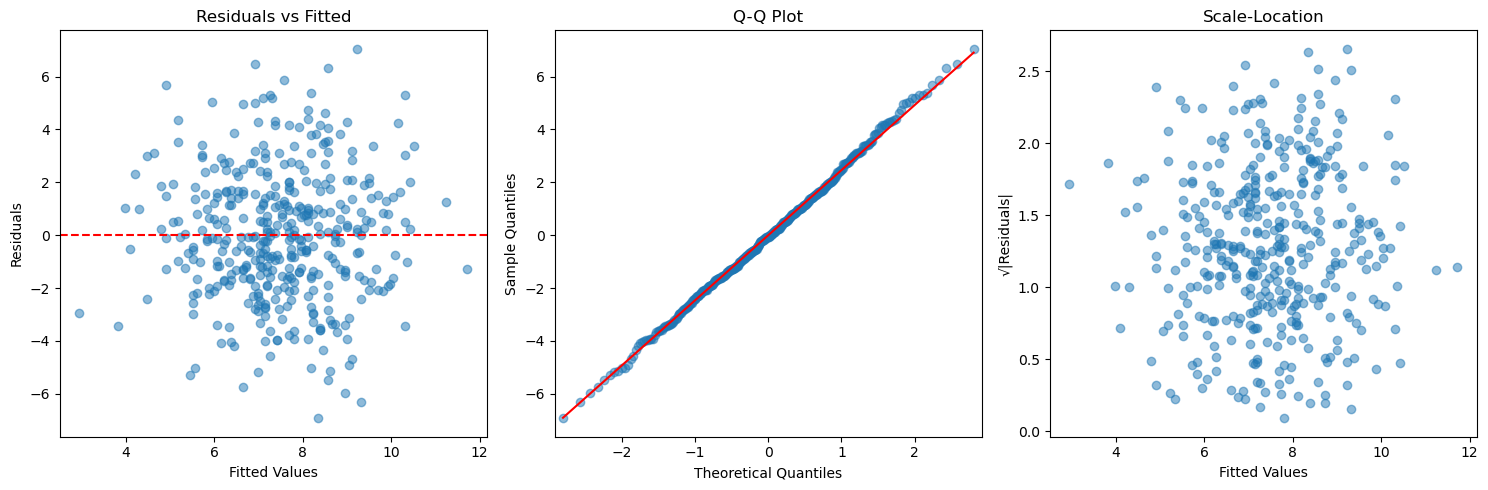

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Residuals vs Fitted
fitted = model_e.fittedvalues
residuals = model_e.resid
axes[0].scatter(fitted, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Plot')

# 3. Scale-Location
axes[2].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('√|Residuals|')
axes[2].set_title('Scale-Location')

plt.tight_layout()
plt.show()

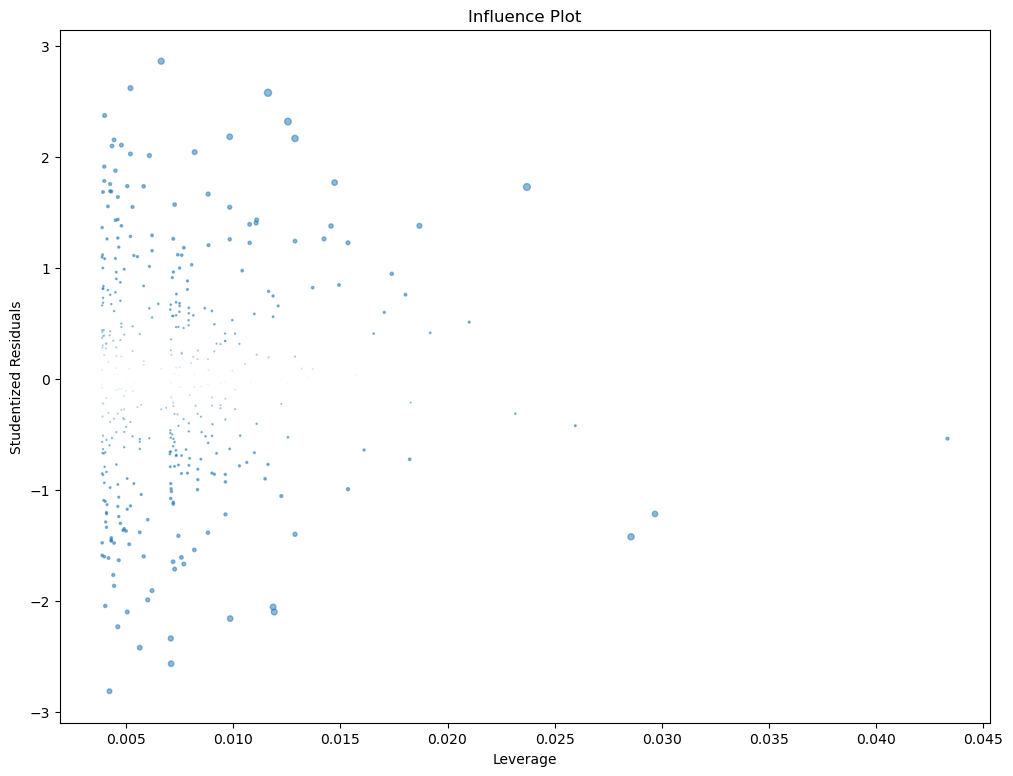

In [25]:
fig, ax = plt.subplots(figsize=(12,9))

influence = model_e.get_influence()
leverage = influence.hat_matrix_diag
resid_student = influence.resid_studentized_internal
cooks = influence.cooks_distance[0]

ax.scatter(leverage, resid_student, s=1000*cooks, alpha=0.5)
ax.set_xlabel('Leverage')
ax.set_ylabel('Studentized Residuals')
ax.set_title('Influence Plot')

for i in range(len(leverage)):
    if leverage[i] > 0.08 or abs(resid_student[i]) > 3:
        ax.annotate(Carseats.index[i], (leverage[i], resid_student[i]), fontsize=8,
                    xytext=(5,5), textcoords='offset points')

plt.show()

The Residuals vs Fitted plot shows points randomly scattered above and 
below zero with no clear pattern, suggesting the linearity assumption 
is reasonably satisfied. However, a few observations with residuals as 
large as 6 and as small as -6 may indicate the presence of some outliers. 
The Q-Q plot shows residuals are approximately normally distributed, with 
slight deviations at the tails suggesting a small number of extreme 
observations. The Scale-Location plot shows relatively even spread across 
all fitted values, suggesting no major issues with heteroscedasticity. 
The influence plot shows most observations have low leverage, though a 
few points with leverage values around 0.030 - 0.044 warrant attention. 
Overall, while there is some evidence of a few outliers, there are no 
observations with extremely high leverage that would severely influence 
the model.

# Q12
This problem involves simple linear regression without an intercept.

(a) Recall that the coefficient estimate βˆ for the linear regression of Y onto X without an intercept is given by (3.38). Under what circumstance is the coefficient estimate for the regression of X onto Y the same as the coefficient estimate for the regression of Y onto X?

(b) Generate an example in Python with n = 100 observations in which the coefficient estimate for the regression of X onto Y is different from the coefficient estimate for the regression of Y onto X.

(c) Generate an example in Python with n = 100 observations in which the coefficient estimate for the regression of X onto Y is the same as the coefficient estimate for the regression of Y onto X.

### (a)

The coefficient estimate $\hat{\beta}$ for the regression of Y onto X 
without an intercept is given by:

$$\hat{\beta}_{Y \sim X} = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}$$

Similarly, the coefficient estimate for the regression of X onto Y is:

$$\hat{\beta}_{X \sim Y} = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} y_i^2}$$

For these two coefficients to be equal, the denominators must be equal:

$$\sum_{i=1}^{n} x_i^2 = \sum_{i=1}^{n} y_i^2$$

Therefore, the coefficient estimate for the regression of X onto Y will 
equal the coefficient estimate for the regression of Y onto X when X and 
Y have the same sum of squared values — that is, when X and Y vary by 
the same amount around zero.

### (b)

In [26]:
np.random.seed(42)  # for reproducibility

# Generate random data
n = 100
X = np.random.randn(n)  # 100 random values for X
Y = 2 * X + np.random.randn(n)  # Y depends on X plus some random noise

# Regression of Y onto X (no intercept)
model_yx = sm.OLS(Y, X).fit()
print("Coefficient Y onto X:", model_yx.params[0].round(4))

# Regression of X onto Y (no intercept)
model_xy = sm.OLS(X, Y).fit()
print("Coefficient X onto Y:", model_xy.params[0].round(4))

Coefficient Y onto X: 1.8558
Coefficient X onto Y: 0.4113


In this example, Y was generated as $Y = 2X + \epsilon$ where $\epsilon$ 
represents random noise. Since Y depends on X plus additional noise, X 
and Y have different sums of squared values 
($\sum_{i=1}^{n} x_i^2 \neq \sum_{i=1}^{n} y_i^2$), resulting in 
different coefficient estimates. The coefficient for the regression of 
Y onto X is $\hat{\beta}_{Y \sim X} = 1.8558$, while the coefficient 
for the regression of X onto Y is $\hat{\beta}_{X \sim Y} = 0.4113$ 
— clearly different values, confirming that when X and Y have different 
sums of squared values, the two regression coefficients will not be equal.

### (c)

In [27]:
np.random.seed(42)

# Generate X
n = 100
X = np.random.randn(n)

# Y is just X values scrambled in different order
Y = np.random.permutation(X)

# Regression of Y onto X (no intercept)
model_yx2 = sm.OLS(Y, X).fit()
print("Coefficient Y onto X:", model_yx2.params[0].round(4))

# Regression of X onto Y (no intercept)
model_xy2 = sm.OLS(X, Y).fit()
print("Coefficient X onto Y:", model_xy2.params[0].round(4))

# Verify sum of squares are equal
print("\nSum of squares X:", (X**2).sum().round(4))
print("Sum of squares Y:", (Y**2).sum().round(4))

Coefficient Y onto X: 0.0736
Coefficient X onto Y: 0.0736

Sum of squares X: 82.7306
Sum of squares Y: 82.7306


In this example, Y was generated as a **permutation** (scrambled version) 
of X — meaning Y contains the exact same values as X, just in a different 
order. Because Y contains the same values as X, their sums of squared 
values are identical ($\sum_{i=1}^{n} x_i^2 = 82.7306$ and 
$\sum_{i=1}^{n} y_i^2 = 82.7306$). This satisfies the condition from 
part (a), resulting in identical coefficient estimates for both regressions. 
The coefficient for the regression of Y onto X is 
$\hat{\beta}_{Y \sim X} = 0.0736$, and the coefficient for the regression 
of X onto Y is $\hat{\beta}_{X \sim Y} = 0.0736$, confirming that when 
$\sum_{i=1}^{n} x_i^2 = \sum_{i=1}^{n} y_i^2$, the two regression 
coefficients are equal.